# Aufgabe-6 | Morphologische Filter

#### Ahmed Adnan - Eugen Erb - Nicolas Huhle

## Morphological Operations – Summary
<b>Goal:</b> Modify shapes in images using filters (structuring elements).

### Main operations:

    Erosion: Shrinks bright (white) areas → removes noise, separates objects.
    Dilation: Expands bright areas → fills gaps, connects regions.

### Works on grayscale images by sliding a filter (e.g. 3x3 matrix) over the image:
    Grayscale Erosion: pixel = minimum of (image region - filter)
    Grayscale Dilation: pixel = maximum of (image region + filter)

### Structuring element: defines the shape and size of the filter window (e.g. square, cross).

#### Useful for:
    Removing small artifacts
    Smoothing object boundaries
    Preparing images for object detection

### e.g of Binary Dilation
The structuring element is "grown" over the image.

Source: Abbildung 10.8
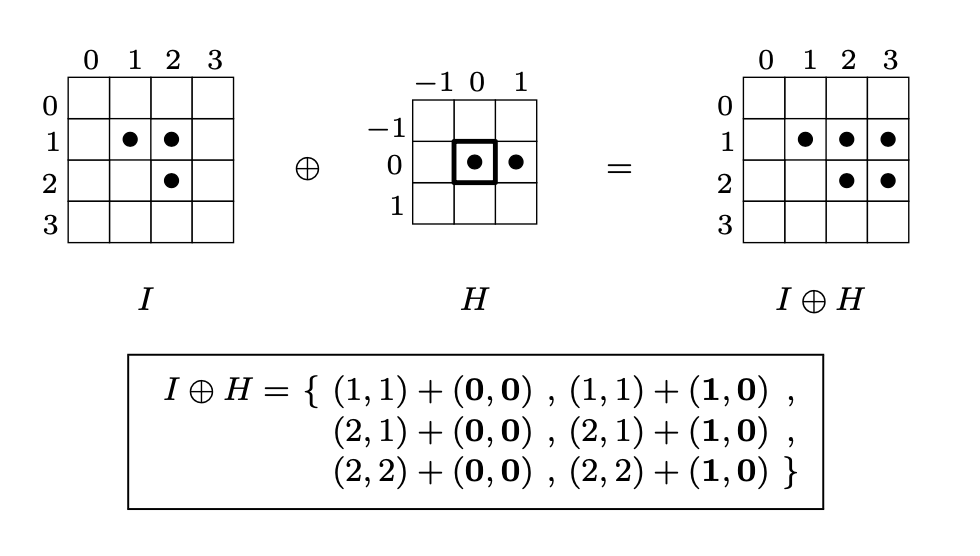

### e.g of Binary Erosion
The image is “shrunk” where the structuring element fully fits inside foreground pixels.

Source: Abbildung 10.9
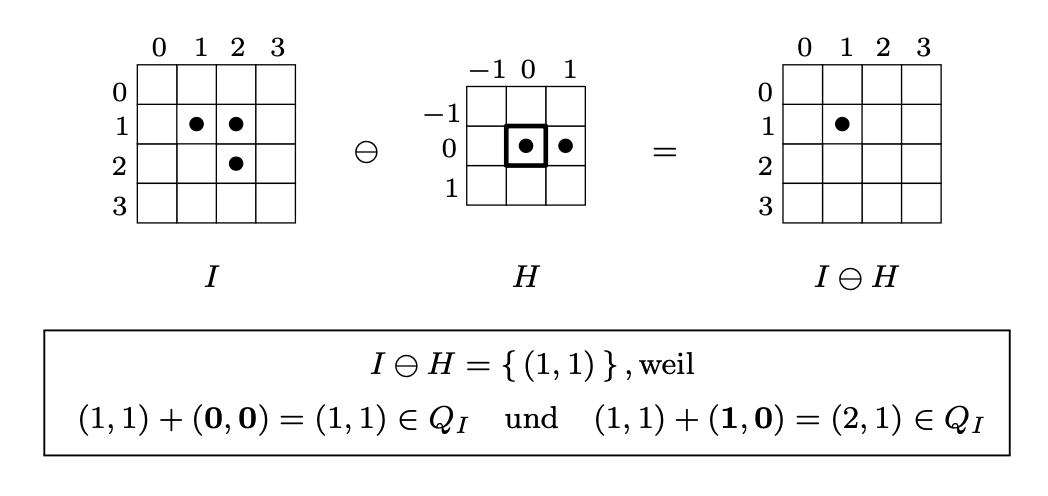

## Preview Input Images

Before starting with morphological filtering, let's load and display the grayscale images we'll be working with:
- `cactus.jpg`
- `dots.jpg`
- `edge.jpg`
- `fhorn.jpg`

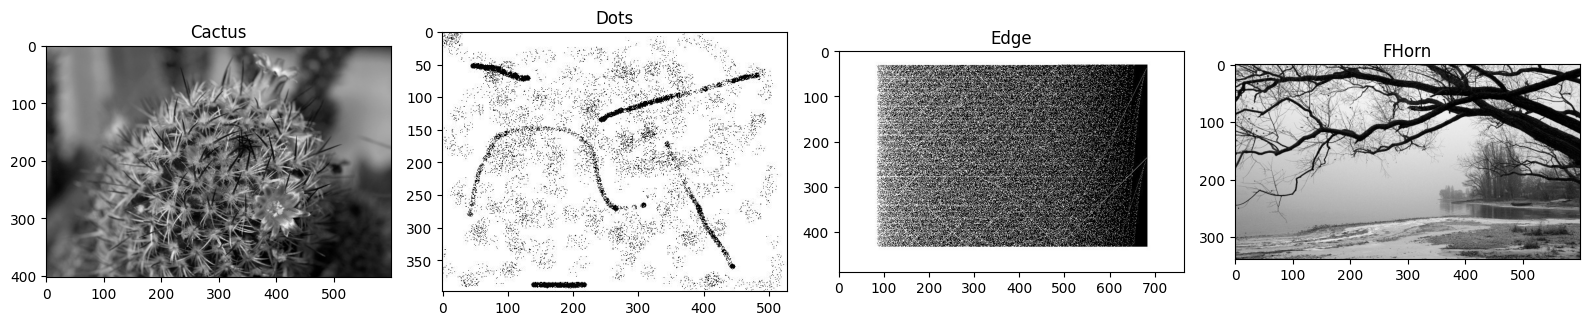

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from scipy.ndimage import grey_erosion, grey_dilation

cactus = np.array(Image.open("cactus.jpg").convert("L"))# convert("L") converts to grayscale from PIL lib
dots = np.array(Image.open("dots.jpg").convert("L"))
edge = np.array(Image.open("edge.jpg").convert("L"))
fhorn = np.array(Image.open("fhorn.jpg").convert("L"))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
images = [cactus, dots, edge, fhorn]
titles = ["Cactus", "Dots", "Edge", "FHorn"]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)

plt.tight_layout()
plt.show()


#### Before implementing anything, lets handle the edges correctly:

In [14]:
def pad_image(img, filter_shape):
    """Pad the image with edge values based on filter size."""
    pad_y = filter_shape[0] // 2
    pad_x = filter_shape[1] // 2
    return np.pad(img, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')

## Define Morphological Operation Functions

We define the basic function interfaces for the morphological operations:
- `erode()`: shrinks bright regions in an image.
- `dilate()`: expands bright regions in an image.

Each function takes:
- `in_image`: Grayscale input image (2D NumPy array)
- `filter`: Structuring element (2D NumPy array)
- `iter_num`: Number of times to apply the operation

In [23]:
def erode(in_image: np.ndarray, filter: np.ndarray, iter_num: int) -> np.ndarray:
    """
    Apply manual grayscale erosion.

    Grayscale erosion works by sliding a filter (structuring element) across the image
    and replacing each pixel with the minimum of (image region - filter).
    This has the effect of shrinking bright areas and removing small bright noise.

    Parameters:
        in_image (np.ndarray): Input grayscale image.
        filter (np.ndarray): Structuring element (2D).
        iter_num (int): Number of erosion iterations.

    Returns:
        np.ndarray: Eroded image.
    """
    out_image = in_image.copy()
    filter_h, filter_w = filter.shape

    for _ in range(iter_num):
        # Pad the image to handle borders
        padded = pad_image(out_image, filter.shape)
        result = np.zeros_like(out_image)

        # Apply erosion to every pixel
        for y in range(out_image.shape[0]):
            for x in range(out_image.shape[1]):
                # Extract local region
                region = padded[y:y+filter_h, x:x+filter_w]
                # Compute minimum of (region - filter)
                result[y, x] = np.min(region - filter)

        out_image = result

    return out_image


In [24]:
def dilate(in_image: np.ndarray, filter: np.ndarray, iter_num: int) -> np.ndarray:
    """
    Apply manual grayscale dilation.

    Grayscale dilation works by sliding a filter (structuring element) across the image
    and replacing each pixel with the maximum of (image region + filter).
    This expands bright regions and fills small dark holes.

    Parameters:
        in_image (np.ndarray): Input grayscale image.
        filter (np.ndarray): Structuring element (2D).
        iter_num (int): Number of dilation iterations.

    Returns:
        np.ndarray: Dilated image.
    """
    out_image = in_image.copy()
    filter_h, filter_w = filter.shape

    for _ in range(iter_num):
        # Pad the image to handle borders
        padded = pad_image(out_image, filter.shape)
        result = np.zeros_like(out_image)

        # Apply dilation to every pixel
        for y in range(out_image.shape[0]):
            for x in range(out_image.shape[1]):
                # Extract local region
                region = padded[y:y+filter_h, x:x+filter_w]
                # Compute maximum of (region + filter)
                result[y, x] = np.max(region + filter)

        out_image = result

    return out_image

##  Test Morphological Operations with Images

We now test our  `erode()` and `dilate()` functions using the input images.
- Use a simple 3×3 structuring element (all ones)
- Apply both operations with different iteration counts
- Display the results to see the effects of erosion and dilation visually


In [28]:
#3x3 square structuring element
structuring_element = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)

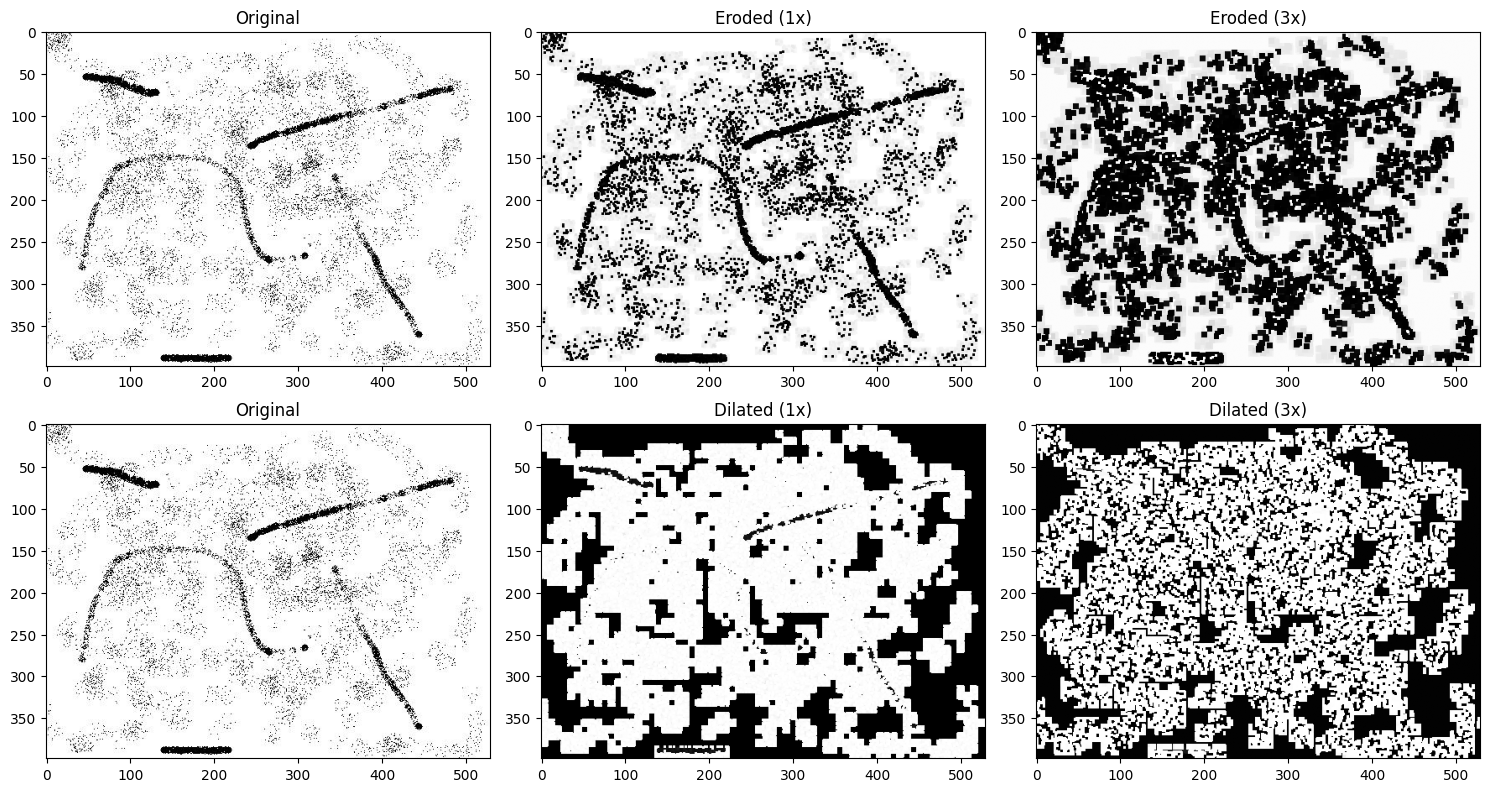

In [31]:
input_img = dots

# erosion and dilation with 1 iteration
eroded_1 = erode(input_img, structuring_element, iter_num=1)
dilated_1 = dilate(input_img, structuring_element, iter_num=1)

# 3 iterations
eroded_3 = erode(input_img, structuring_element, iter_num=3)
dilated_3 = dilate(input_img, structuring_element, iter_num=3)

# Display results side by side
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
titles = [
    "Original", "Eroded (1x)", "Eroded (3x)",
    "Original", "Dilated (1x)", "Dilated (3x)"
]
images = [input_img, eroded_1, eroded_3,
          input_img, dilated_1, dilated_3]

for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)

plt.tight_layout()
plt.show()


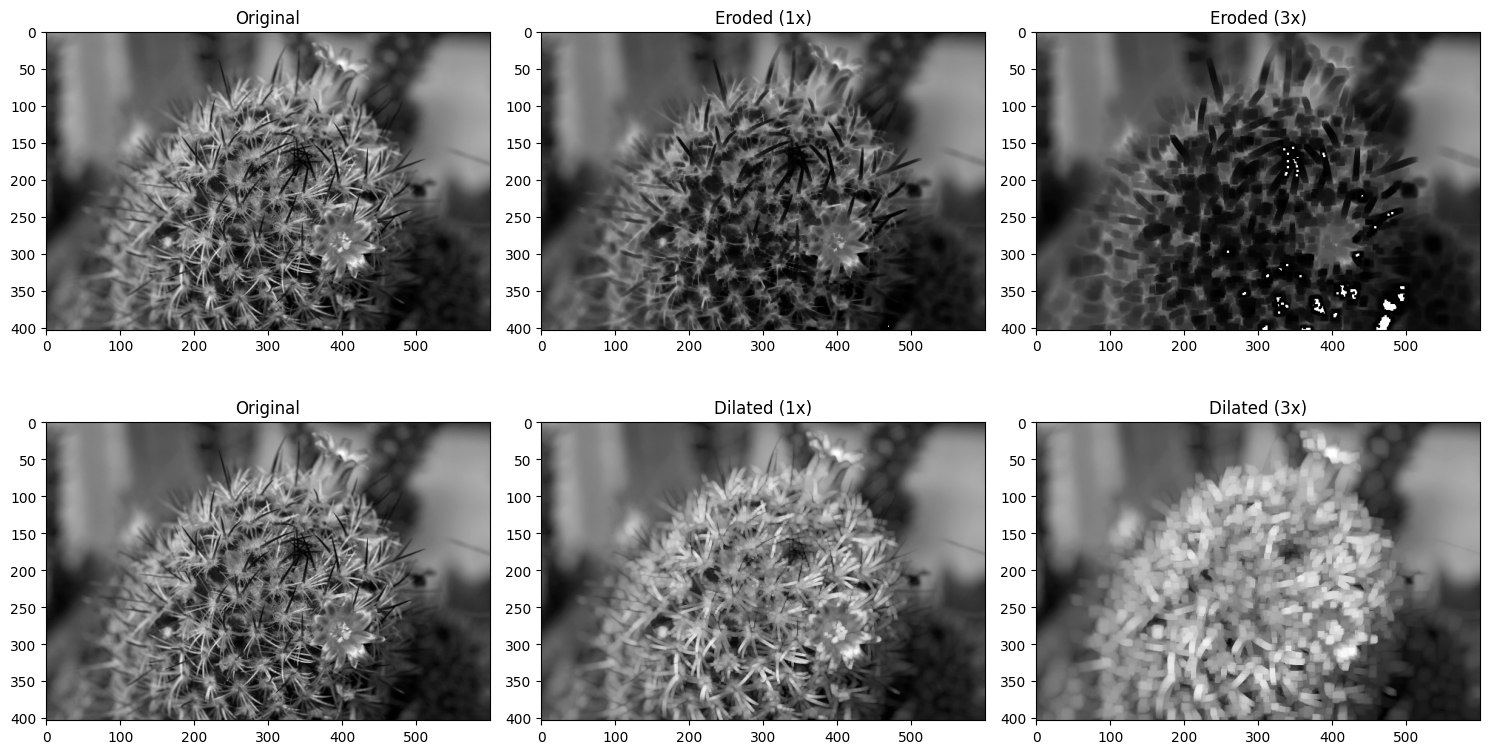

In [37]:
input_img2 = cactus

# erosion and dilation with 1 iteration
eroded_1 = erode(input_img2, structuring_element, iter_num=1)
dilated_1 = dilate(input_img2, structuring_element, iter_num=1)

# 3 iterations
eroded_3 = erode(input_img2, structuring_element, iter_num=3)
dilated_3 = dilate(input_img2, structuring_element, iter_num=3)

# Display results side by side
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
titles = [
    "Original", "Eroded (1x)", "Eroded (3x)",
    "Original", "Dilated (1x)", "Dilated (3x)"
]
images = [input_img2, eroded_1, eroded_3,
          input_img2, dilated_1, dilated_3]

for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)

plt.tight_layout()
plt.show()


## Experiment with Different Structuring Elements

In this step, we'll test how different structuring elements (shapes and sizes) influence the result of erosion and dilation.

We'll try:
- Square (3×3)
- Cross (3×3)
- Horizontal line (1×5)
- Vertical line (5×1)

And visualize how they affect the structure of the image differently.


In [33]:
# Structuring Elements
square_3x3 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)

cross_3x3 = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=np.uint8)

horizontal_1x5 = np.array([
    [1, 1, 1, 1, 1]
], dtype=np.uint8)

vertical_5x1 = np.array([
    [1],
    [1],
    [1],
    [1],
    [1]
], dtype=np.uint8)


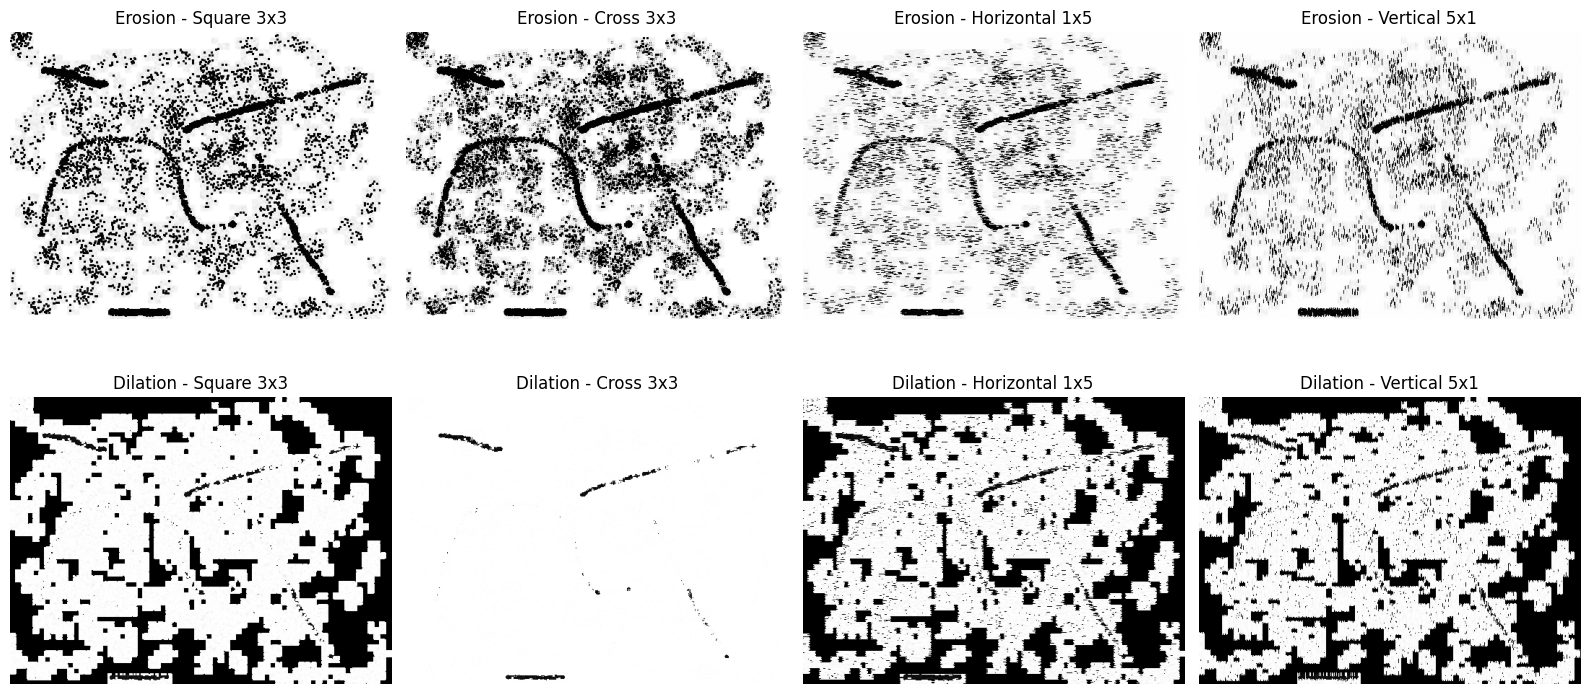

In [38]:
input_img = dots  # or cactus, edge, fhorn

filters = [square_3x3, cross_3x3, horizontal_1x5, vertical_5x1]
titles = ["Square 3x3", "Cross 3x3", "Horizontal 1x5", "Vertical 5x1"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Apply and display erosion
for i, f in enumerate(filters):
    result = erode(input_img, f, iter_num=1)
    axes[0, i].imshow(result, cmap="gray")
    axes[0, i].set_title(f"Erosion - {titles[i]}")
    axes[0, i].axis("off")

# Apply and display dilation
for i, f in enumerate(filters):
    result = dilate(input_img, f, iter_num=1)
    axes[1, i].imshow(result, cmap="gray")
    axes[1, i].set_title(f"Dilation - {titles[i]}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()
